In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

from scipy.stats import chi2_contingency
import itertools
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as sch


from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('preprocessing-1.csv')

In [3]:
df.head()

,crash_date,district,zone,crash_occurred_on,type_of_roadway,road_surface,weather_condition,lighting_condition,injury,fatality,...,total_vehicles,vehicle_alignment,relation_to_roadway,manner_of_collision,primary_factor,secondary_factor,latitude,longitude,day_of_week,crash_month
0,2025-09-19,10,Other,interstate,one-way road,dry,clear,dark - not lighted,1,0,...,2,straight,on roadway,Sideswipe,violations,movement prior to crash,30.478015,-91.167079,friday,9
1,2025-09-18,11,3c-3,city street,two-way road with a physical barrier,dry,clear,daylight,1,0,...,2,straight,on roadway,Rear-End,violations,movement prior to crash,30.415450,-91.062569,thursday,9
2,2025-09-18,8,3e-2,city street,two-way road with a physical barrier,dry,clear,daylight,1,0,...,2,straight,on roadway,Angle,violations,movement prior to crash,30.429276,-91.056297,thursday,9
3,2025-09-18,8,3f-3,city street,two-way road with a physical barrier,dry,clear,daylight,1,0,...,2,straight,on roadway,Angle,violations,movement prior to crash,30.410795,-91.051446,thursday,9
4,2025-09-18,9,3f-1,city street,two-way road with a physical barrier,dry,clear,daylight,1,0,...,2,straight,on roadway,Rear-End,violations,movement prior to crash,30.427169,-91.007492,thursday,9


In [4]:
df['crash_date'] = pd.to_datetime(df['crash_date'])

In [5]:
df.columns


Index(['crash_date', 'district', 'zone', 'crash_occurred_on',
       'type_of_roadway', 'road_surface', 'weather_condition',
       'lighting_condition', 'injury', 'fatality', 'hit_and_run',
       'pedestrian_involved', 'train_involved', 'intersection',
       'total_vehicles', 'vehicle_alignment', 'relation_to_roadway',
       'manner_of_collision', 'primary_factor', 'secondary_factor', 'latitude',
       'longitude', 'day_of_week', 'crash_month'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45385 entries, 0 to 45384
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   crash_date           45385 non-null  datetime64[ns]
 1   district             45385 non-null  int64         
 2   zone                 45385 non-null  object        
 3   crash_occurred_on    45385 non-null  object        
 4   type_of_roadway      45385 non-null  object        
 5   road_surface         45385 non-null  object        
 6   weather_condition    45385 non-null  object        
 7   lighting_condition   45385 non-null  object        
 8   injury               45385 non-null  int64         
 9   fatality             45385 non-null  int64         
 10  hit_and_run          45385 non-null  int64         
 11  pedestrian_involved  45385 non-null  int64         
 12  train_involved       45385 non-null  int64         
 13  intersection         45385 non-

Displaying histograms of new binned attributes...


/var/folders/4z/9ddz1dxn051gf97hvy69q3f80000gn/T/ipykernel_2677/4254512525.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], data=df, x='lat_bin', palette='viridis')
/var/folders/4z/9ddz1dxn051gf97hvy69q3f80000gn/T/ipykernel_2677/4254512525.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], data=df, x='lon_bin', palette='plasma')


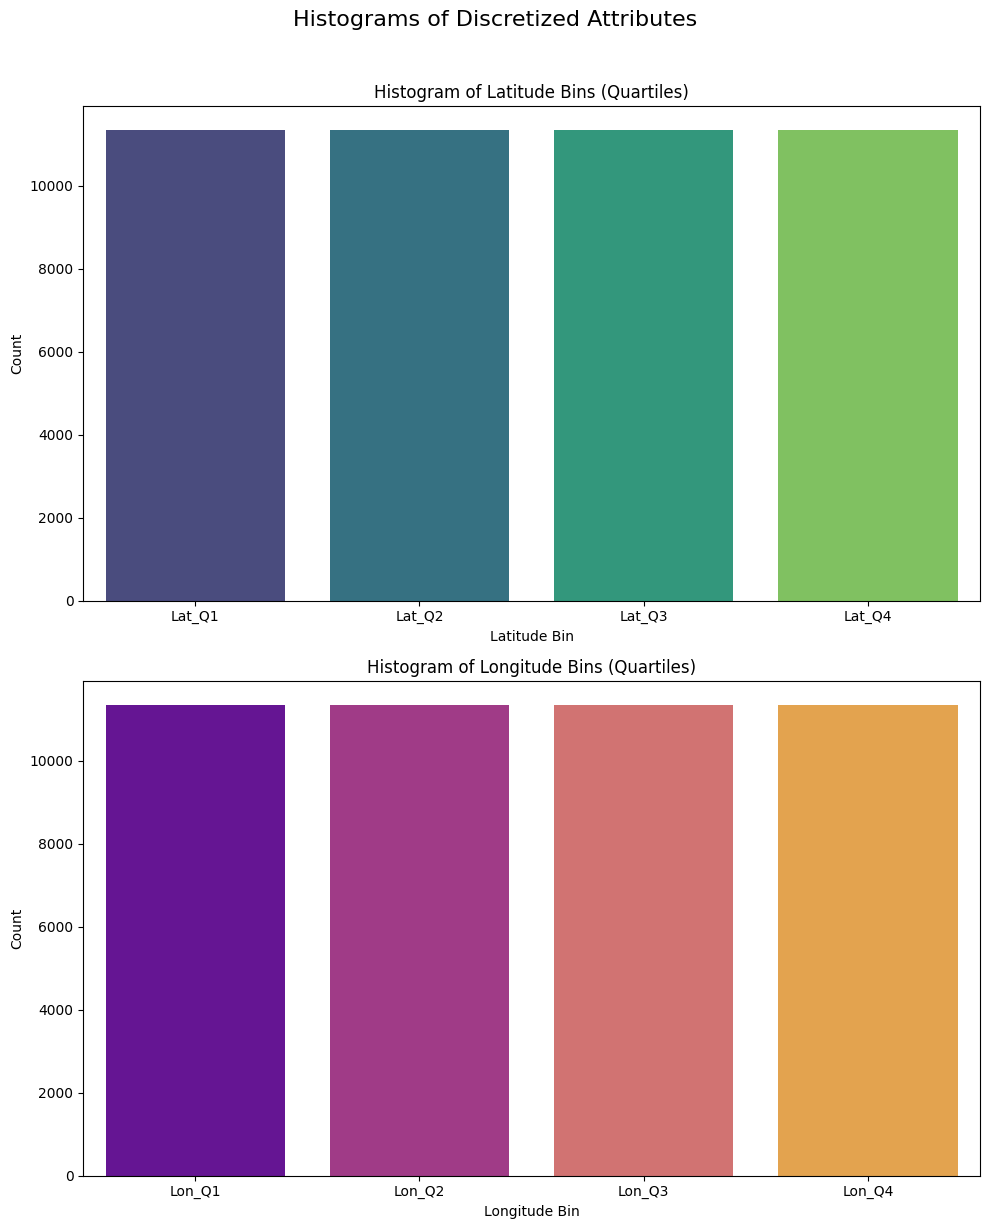

In [7]:
# --- 2. Apply Partitioning (Discretization) ---

# A. Equal-Frequency (Quantile) Binning for Lat/Lon
# We'll use 4 bins (quartiles)
# 'labels=False' makes them 0, 1, 2, 3. You can also use text labels.
df['lat_bin'] = pd.qcut(df['latitude'], q=4, labels=['Lat_Q1', 'Lat_Q2', 'Lat_Q3', 'Lat_Q4'])
df['lon_bin'] = pd.qcut(df['longitude'], q=4, labels=['Lon_Q1', 'Lon_Q2', 'Lon_Q3', 'Lon_Q4'])

# --- 3. Plot Histograms of Discretized Attributes ---
print("Displaying histograms of new binned attributes...")

fig, axes = plt.subplots(2, 1, figsize=(10, 12))
fig.suptitle('Histograms of Discretized Attributes', fontsize=16, y=1.02)

# Plot 1: Latitude Bins
sns.countplot(ax=axes[0], data=df, x='lat_bin', palette='viridis')
axes[0].set_title('Histogram of Latitude Bins (Quartiles)')
axes[0].set_xlabel('Latitude Bin')
axes[0].set_ylabel('Count')

# Plot 2: Longitude Bins
sns.countplot(ax=axes[1], data=df, x='lon_bin', palette='plasma')
axes[1].set_title('Histogram of Longitude Bins (Quartiles)')
axes[1].set_xlabel('Longitude Bin')
axes[1].set_ylabel('Count')


plt.tight_layout()
plt.show()

Distribution of 'total_vehicles':
total_vehicles
1     3752
2    38467
3     2657
4      401
5       82
6       17
7        5
8        3
9        1
Name: count, dtype: int64

Displaying histogram of 'vehicle_bin'...


/var/folders/4z/9ddz1dxn051gf97hvy69q3f80000gn/T/ipykernel_2677/2394021108.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='vehicle_bin', palette='Spectral')


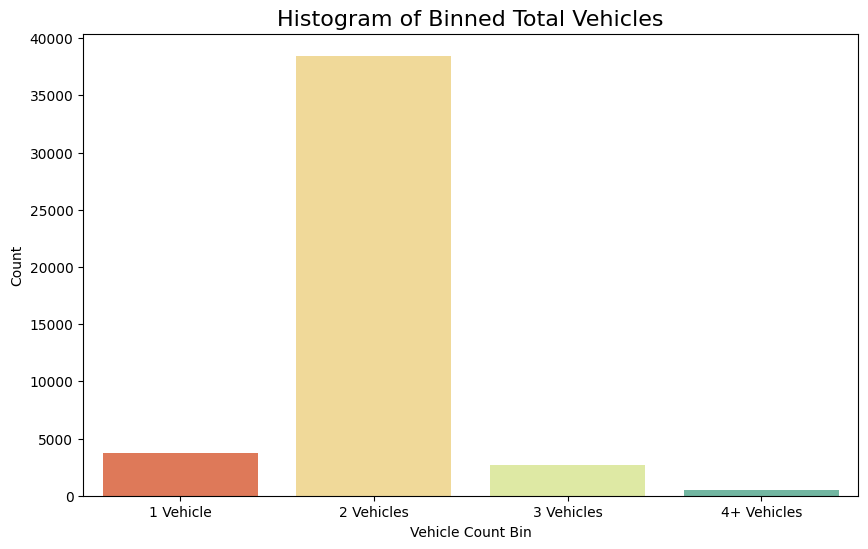

In [9]:
# --- 2. Inspect the 'total_vehicles' column ---
# Let's see the distribution to make smart bins
print("Distribution of 'total_vehicles':")
# Sort by the index (number of vehicles) to make it readable
print(df['total_vehicles'].value_counts().sort_index())

# --- 3. Apply Partitioning (Discretization) ---
# Based on the output, we'll create bins.
# Let's assume most crashes are 1 or 2 vehicles.
# We'll create bins for: 1, 2, 3, and 4 or more.
# Bins: [0, 1, 2, 3, max_value]
# This creates bins: (0-1], (1-2], (2-3], (3-max]
# which correspond to labels: '1', '2', '3', '4+'

# Get the max number of vehicles
max_vehicles = df['total_vehicles'].max()

# Define the bin edges
# We use np.inf for "and above"
vehicle_bins = [0, 1, 2, 3, np.inf] 
vehicle_labels = ['1 Vehicle', '2 Vehicles', '3 Vehicles', '4+ Vehicles']

# Use pd.cut
df['vehicle_bin'] = pd.cut(df['total_vehicles'], 
                           bins=vehicle_bins, 
                           labels=vehicle_labels)

# --- 4. Plot Histogram of the New Bins ---
print("\nDisplaying histogram of 'vehicle_bin'...")

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='vehicle_bin', palette='Spectral')
plt.title('Histogram of Binned Total Vehicles', fontsize=16)
plt.xlabel('Vehicle Count Bin')
plt.ylabel('Count')
plt.show()

In [11]:
# --- 1. Chi-Square Test of Independence ---

# Test 1: vehicle_bin vs. injury
print("--- Test 1: Vehicle Bins vs. Injury ---")
# Create the contingency table (cross-tabulation)
contingency_table_veh = pd.crosstab(df['vehicle_bin'], df['injury'])
print("Contingency Table:")
print(contingency_table_veh)

# Run the test
chi2, p_val, dof, expected = chi2_contingency(contingency_table_veh)
print(f"\nChi-Square Value: {chi2}")
print(f"P-Value: {p_val}")

if p_val < 0.05:
    print("Result: The variables are DEPENDENT (p < 0.05).")
else:
    print("Result: The variables are INDEPENDENT (p > 0.05).")


# Test 2: lat_bin vs. lon_bin
print("\n\n--- Test 2: Latitude Bins vs. Longitude Bins ---")
contingency_table_loc = pd.crosstab(df['lat_bin'], df['lon_bin'])
print("Contingency Table (snippet):")
print(contingency_table_loc.head())

# Run the test
chi2, p_val, dof, expected = chi2_contingency(contingency_table_loc)
print(f"\nChi-Square Value: {chi2}")
print(f"P-Value: {p_val}")

if p_val < 0.05:
    print("Result: The variables are DEPENDENT (p < 0.05).")
else:
    print("Result: The variables are INDEPENDENT (p > 0.05).")

--- Test 1: Vehicle Bins vs. Injury ---
Contingency Table:
injury          0      1
vehicle_bin             
1 Vehicle    1316   2436
2 Vehicles   7581  30886
3 Vehicles   1104   1553
4+ Vehicles   267    242

Chi-Square Value: 1321.5834028096037
P-Value: 3.0522913539131864e-286
Result: The variables are DEPENDENT (p < 0.05).


--- Test 2: Latitude Bins vs. Longitude Bins ---
Contingency Table (snippet):
lon_bin  Lon_Q1  Lon_Q2  Lon_Q3  Lon_Q4
lat_bin                                
Lat_Q1     2377    1987    4402    2581
Lat_Q2     2324    3351    1262    4410
Lat_Q3     3742    1959    2681    2963
Lat_Q4     2905    4051    2998    1392

Chi-Square Value: 4989.898133978713
P-Value: 0.0
Result: The variables are DEPENDENT (p < 0.05).


Test 1: Vehicle Bins vs. Injury
P-Value: 3.05e-286. This is an extremely small number (0.000... with 285 zeros).

Result: DEPENDENT.

What it means: There is a strong, statistically significant relationship between the number of vehicles in a crash and whether an injury occurs. This confirms our intuition that vehicle_bin is a very important predictive feature.

Deeper Insight (from your Contingency Table):

1 Vehicle: 1316 (No Injury) vs. 2436 (Injury) → ~65% injury rate

2 Vehicles: 7581 (No Injury) vs. 30886 (Injury) → ~80% injury rate

3 Vehicles: 1104 (No Injury) vs. 1553 (Injury) → ~58% injury rate

4+ Vehicles: 267 (No Injury) vs. 242 (Injury) → ~47.5% injury rate This is a fantastic insight! The highest risk of injury is in 2-vehicle crashes, not 1-vehicle or multi-car pileups.

Test 2: Latitude Bins vs. Longitude Bins
P-Value: 0.0.

Result: DEPENDENT.

What it means: The geographic "zones" you created are not independent. A crash's latitude bin is related to its longitude bin.

Why this makes sense: This is expected! It simply means the city's layout isn't a perfect square. For example, your Lat_Q1 (southernmost) zone might be very wide, while your Lat_Q4 (northernmost) zone might be very narrow. Your contingency table snippet shows this: Lat_Q1 has a high number of crashes in Lon_Q3, but Lat_Q4 has a high number in Lon_Q2. This just confirms the geographic distribution of crashes is complex.


In [12]:
df.columns

Index(['crash_date', 'district', 'zone', 'crash_occurred_on',
       'type_of_roadway', 'road_surface', 'weather_condition',
       'lighting_condition', 'injury', 'fatality', 'hit_and_run',
       'pedestrian_involved', 'train_involved', 'intersection',
       'total_vehicles', 'vehicle_alignment', 'relation_to_roadway',
       'manner_of_collision', 'primary_factor', 'secondary_factor', 'latitude',
       'longitude', 'day_of_week', 'crash_month', 'lat_bin', 'lon_bin',
       'vehicle_bin'],
      dtype='object')

In [13]:
# 1. List all categorical columns based on the df.info()
categorical_cols = [
    'district', 'zone', 'crash_occurred_on', 'type_of_roadway', 
    'road_surface', 'weather_condition', 'lighting_condition', 'injury', 
    'fatality', 'hit_and_run', 'pedestrian_involved', 'train_involved', 
    'intersection', 'vehicle_alignment', 'relation_to_roadway', 
    'manner_of_collision', 'primary_factor', 'secondary_factor', 
    'day_of_week', 'crash_month', 'vehicle_bin', 'lat_bin', 'lon_bin'
]


# 3. Create all unique pairs of these columns
all_pairs = list(itertools.combinations(categorical_cols, 2))
print(f"\nFound {len(categorical_cols)} categorical columns.")
print(f"Total number of pairs to test: {len(all_pairs)}")

results = []
significance_level = 0.05

# 4. Loop through all pairs and perform the test
print("Running Chi-square tests for all pairs...")
for col1, col2 in all_pairs:
    try:
        # Create contingency table
        contingency_table = pd.crosstab(df[col1], df[col2])
        
        # Run the test
        chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)
        
        # Check the assumption (expected frequency > 5)
        warning = ""
        if (expected_freq < 5).sum() > 0:
            warning = "Warning: (%.1f%%) of cells have expected frequency < 5. Result may be unreliable." % ((expected_freq < 5).mean() * 100)
        
        # Store the result
        results.append({
            'Variable 1': col1,
            'Variable 2': col2,
            'Chi2 Statistic': chi2_stat,
            'P-Value': p_value,
            'Significant (p < 0.05)': p_value < significance_level,
            'Warning': warning
        })
    
    except Exception as e:
        results.append({
            'Variable 1': col1,
            'Variable 2': col2,
            'Chi2 Statistic': np.nan,
            'P-Value': np.nan,
            'Significant (p < 0.05)': False,
            'Warning': f"ERROR: {str(e)}"
        })

# 5. Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(results)

# 6. Filter for and print only the significant results
significant_results = results_df[results_df['Significant (p < 0.05)'] == True]
significant_results = significant_results.sort_values(by='P-Value', ascending=True)

print("\n--- All Significant Relationships (p < 0.05) ---")
print("--- (Sorted by most significant) ---")
if significant_results.empty:
    print("No significant relationships found at the p < 0.05 level.")
else:
    # Using 'to_string' for better formatting in the console
    print(significant_results.to_string(index=False, columns=['Variable 1', 'Variable 2', 'P-Value', 'Warning']))

# 7. Save all results to a CSV file
full_csv_path = "all_chi2_test_results.csv"
results_df.to_csv(full_csv_path, index=False)

print(f"\nDone. Full report for all {len(all_pairs)} pairs saved to: {full_csv_path}")


Found 23 categorical columns.
Total number of pairs to test: 253
Running Chi-square tests for all pairs...

--- All Significant Relationships (p < 0.05) ---
--- (Sorted by most significant) ---
         Variable 1          Variable 2       P-Value                                                                          Warning
           district                zone  0.000000e+00 Warning: (14.4%) of cells have expected frequency < 5. Result may be unreliable.
  weather_condition      primary_factor  0.000000e+00 Warning: (64.8%) of cells have expected frequency < 5. Result may be unreliable.
  weather_condition  lighting_condition  0.000000e+00 Warning: (50.0%) of cells have expected frequency < 5. Result may be unreliable.
       road_surface    secondary_factor  0.000000e+00 Warning: (72.7%) of cells have expected frequency < 5. Result may be unreliable.
       road_surface      primary_factor  0.000000e+00 Warning: (75.0%) of cells have expected frequency < 5. Result may be unrelia

In [14]:
results_df.tail(20)

,Variable 1,Variable 2,Chi2 Statistic,P-Value,Significant (p < 0.05),Warning
233,primary_factor,day_of_week,160.512490,7.650074e-10,True,Warning: (22.6%) of cells have expected freque...
234,primary_factor,crash_month,218.399886,1.417127e-07,True,Warning: (25.0%) of cells have expected freque...
235,primary_factor,vehicle_bin,4301.555652,0.000000e+00,True,Warning: (33.3%) of cells have expected freque...
236,primary_factor,lat_bin,406.030605,8.268105e-66,True,Warning: (16.7%) of cells have expected freque...
237,primary_factor,lon_bin,227.771152,5.795339e-31,True,Warning: (16.7%) of cells have expected freque...
238,secondary_factor,day_of_week,345.562150,2.279222e-37,True,Warning: (17.6%) of cells have expected freque...
239,secondary_factor,crash_month,274.021840,5.544665e-12,True,Warning: (29.5%) of cells have expected freque...
240,secondary_factor,vehicle_bin,1988.295056,0.000000e+00,True,Warning: (32.7%) of cells have expected freque...
241,secondary_factor,lat_bin,225.901747,2.312980e-29,True,Warning: (7.7%) of cells have expected frequen...
242,secondary_factor,lon_bin,745.893185,1.653793e-133,True,Warning: (7.7%) of cells have expected frequen...


Generating heatmap...


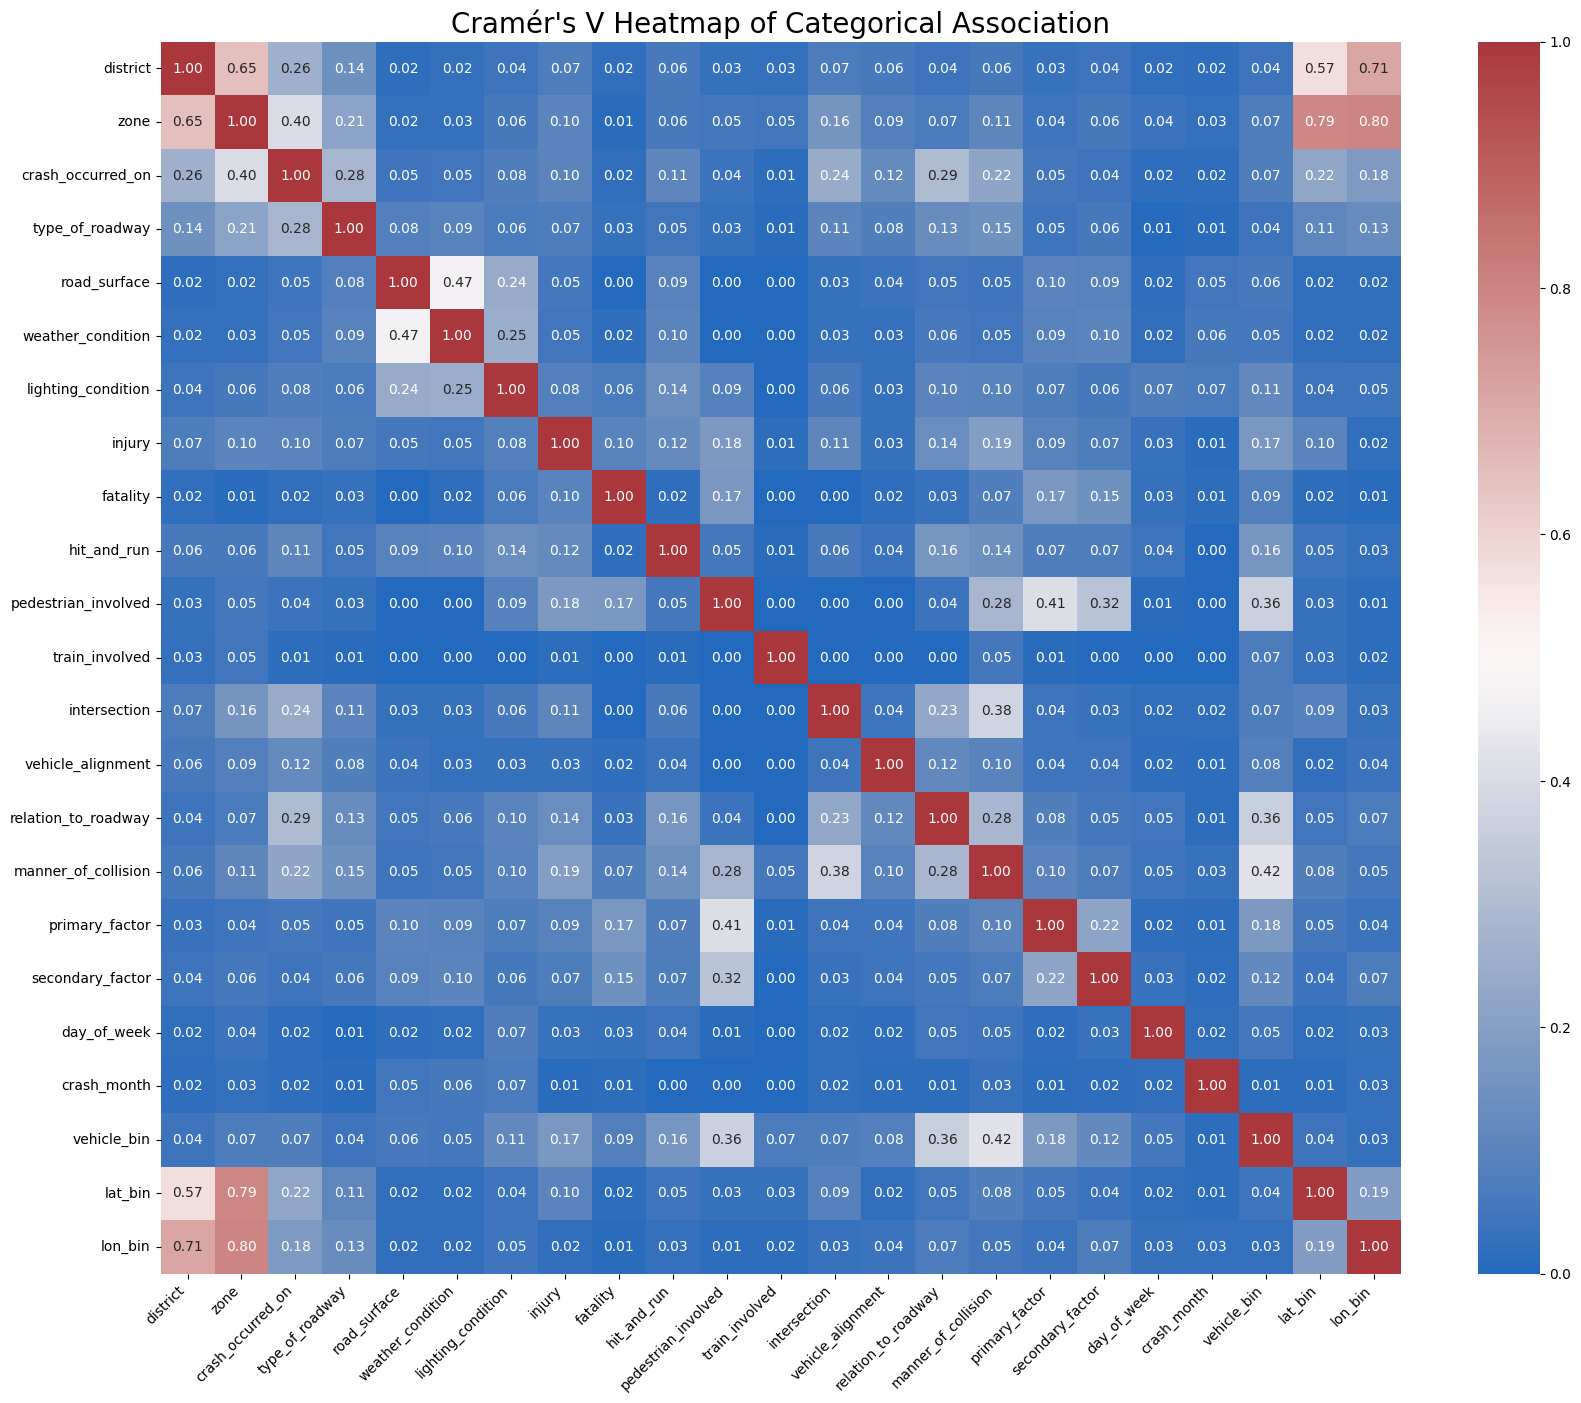

In [15]:

# --- 4. Function to Calculate Cramér's V ---
def cramers_v(contingency_table):
    """ Calculate Cramér's V statistic for categorical-categorical association. """
    try:
        chi2 = chi2_contingency(contingency_table)[0]
        n = contingency_table.sum().sum()
        phi2 = chi2 / n
        r, k = contingency_table.shape
        
        # Apply correction
        phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
        r_corr = r - ((r-1)**2)/(n-1)
        k_corr = k - ((k-1)**2)/(n-1)
        
        if min((k_corr-1), (r_corr-1)) == 0:
            return 0
        else:
            return np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))
    except Exception as e:
        # This can happen if a column has only one value
        # print(f"Cramer's V error: {e}")
        return 0

# --- 5. Build the Association Matrix ---
assoc_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols, dtype=float)

for col1, col2 in itertools.combinations(categorical_cols, 2):
    ct = pd.crosstab(df[col1], df[col2])
    v = cramers_v(ct)
    assoc_matrix.loc[col1, col2] = v
    assoc_matrix.loc[col2, col1] = v

# Fill diagonal with 1s
np.fill_diagonal(assoc_matrix.values, 1.0)

# --- 6. Plot the Heatmap ---
print("Generating heatmap...")
plt.figure(figsize=(20, 16))
sns.heatmap(assoc_matrix, annot=True, cmap='vlag', fmt='.2f', vmin=0, vmax=1)
plt.title("Cramér's V Heatmap of Categorical Association", fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
# plt.savefig('cramers_v_heatmap.png', bbox_inches='tight', dpi=150)


In [16]:
df.drop(['crash_date', 'lat_bin', 'lon_bin', 'total_vehicles', 'zone', 'latitude', 'longitude'], axis=1, inplace=True)

In [17]:
df_cluster = df.copy()

In [18]:
# --- 2. Group 'day_of_week' ---
print("\nGrouping 'day_of_week'...")
if 'day_of_week' in df_cluster.columns:
    weekend_days = ['saturday', 'sunday']
    # .isin() returns True/False. .astype(int) converts to 1/0
    df_cluster['is_weekend'] = df_cluster['day_of_week'].isin(weekend_days).astype(int)
    
    # Drop the original column
    df_cluster = df_cluster.drop('day_of_week', axis=1)
    
    print("New 'is_weekend' counts:")
    print(df_cluster['is_weekend'].value_counts())


# --- 3. Group 'crash_month' ---
print("\nGrouping 'crash_month'...")
if 'crash_month' in df_cluster.columns:
    season_map = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    }
    df_cluster['season'] = df_cluster['crash_month'].map(season_map)
    
    # Drop the original column
    df_cluster = df_cluster.drop('crash_month', axis=1)
    
    print("New 'season' counts:")
    print(df_cluster['season'].value_counts())


# --- 4. Group 'lighting_condition' ---
print("\nGrouping 'lighting_condition'...")
if 'lighting_condition' in df_cluster.columns:
    # This map groups all 'dark...' values and 'unknown'/'other'
    light_map = {
        'daylight': 'Daylight',
        'dawn/dusk': 'Twilight',
        'dark - not lighted': 'Dark',
        'dark - continuous street lights': 'Dark',
        'dark - street lights at intersection only': 'Dark',
        'dark - unknown lighting': 'Dark',
        'unknown': 'Unknown/Other',
        'other': 'Unknown/Other'
    }
    df_cluster['light_group'] = df_cluster['lighting_condition'].map(light_map)
    
    # Fill any values that weren't in the map (just in case)
    df_cluster['light_group'] = df_cluster['light_group'].fillna('Unknown/Other')
    
    # Drop the original column
    df_cluster = df_cluster.drop('lighting_condition', axis=1)

    print("New 'light_group' counts:")
    print(df_cluster['light_group'].value_counts())


# --- 5. Group 'weather_condition' ---
print("\nGrouping 'weather_condition'...")
if 'weather_condition' in df_cluster.columns:
    # This map simplifies the 9 categories into 5 logical groups
    weather_map = {
        'clear': 'Clear/Cloudy',
        'cloudy': 'Clear/Cloudy',
        'rain': 'Rain',
        'freezing rain': 'Snow/Ice',
        'snow': 'Snow/Ice',
        'fog': 'Obscured',
        'severe crosswinds': 'Other/Unknown',
        'unknown': 'Other/Unknown',
        'other': 'Other/Unknown'
    }
    df_cluster['weather_group'] = df_cluster['weather_condition'].map(weather_map)
    
    # Fill any values that weren't in the map
    df_cluster['weather_group'] = df_cluster['weather_group'].fillna('Other/Unknown')
    
    # Drop the original column
    df_cluster = df_cluster.drop('weather_condition', axis=1)

    print("New 'weather_group' counts:")
    print(df_cluster['weather_group'].value_counts())


Grouping 'day_of_week'...
New 'is_weekend' counts:
is_weekend
0    35245
1    10140
Name: count, dtype: int64

Grouping 'crash_month'...
New 'season' counts:
season
Fall      12441
Spring    11749
Summer    10785
Winter    10410
Name: count, dtype: int64

Grouping 'lighting_condition'...
New 'light_group' counts:
light_group
Daylight         33292
Dark             10263
Twilight          1061
Unknown/Other      769
Name: count, dtype: int64

Grouping 'weather_condition'...
New 'weather_group' counts:
weather_group
Clear/Cloudy     41748
Rain              2832
Other/Unknown      699
Obscured            71
Snow/Ice            35
Name: count, dtype: int64


In [19]:
df_cluster.columns

Index(['district', 'crash_occurred_on', 'type_of_roadway', 'road_surface',
       'injury', 'fatality', 'hit_and_run', 'pedestrian_involved',
       'train_involved', 'intersection', 'vehicle_alignment',
       'relation_to_roadway', 'manner_of_collision', 'primary_factor',
       'secondary_factor', 'vehicle_bin', 'is_weekend', 'season',
       'light_group', 'weather_group'],
      dtype='object')

In [20]:
# One-hot encoding
df_encoded = pd.get_dummies(df_cluster)
df_encoded.head()

,district,injury,fatality,hit_and_run,pedestrian_involved,train_involved,intersection,is_weekend,crash_occurred_on_city street,crash_occurred_on_interstate,...,season_Winter,light_group_Dark,light_group_Daylight,light_group_Twilight,light_group_Unknown/Other,weather_group_Clear/Cloudy,weather_group_Obscured,weather_group_Other/Unknown,weather_group_Rain,weather_group_Snow/Ice
0,10,1,0,1,0,0,False,0,False,True,...,False,True,False,False,False,True,False,False,False,False
1,11,1,0,0,0,0,True,0,True,False,...,False,False,True,False,False,True,False,False,False,False
2,8,1,0,0,0,0,True,0,True,False,...,False,False,True,False,False,True,False,False,False,False
3,8,1,0,0,0,0,False,0,True,False,...,False,False,True,False,False,True,False,False,False,False
4,9,1,0,0,0,0,False,0,True,False,...,False,False,True,False,False,True,False,False,False,False


In [21]:
df_encoded.shape

(45385, 95)

In [22]:
# Standard Scaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

In [23]:
# Performing PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(df_scaled)


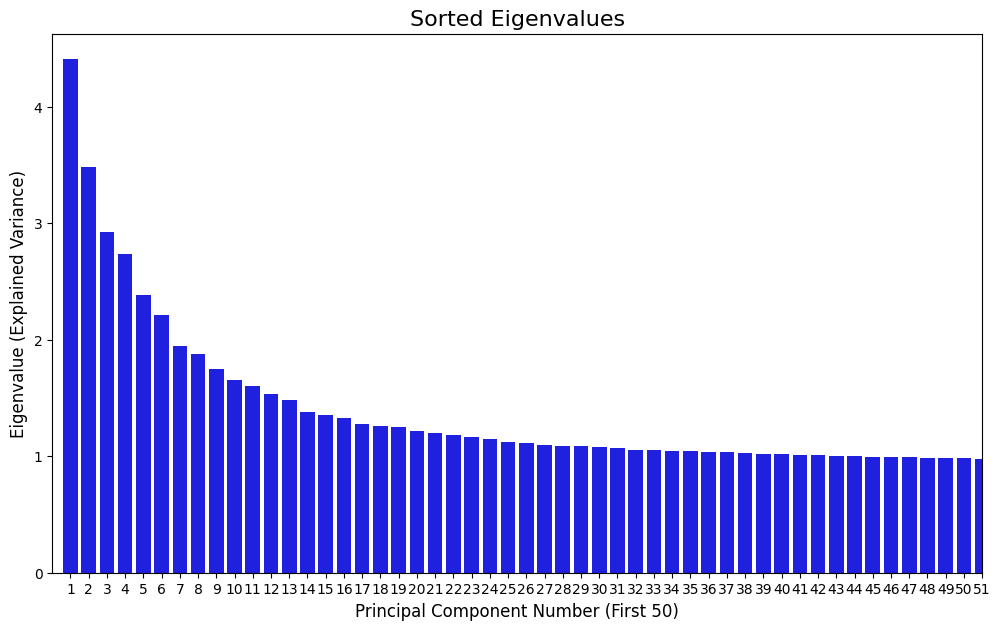

In [24]:
eigenvalues = pca.explained_variance_

plt.figure(figsize=(12, 7))
sns.barplot(
    x=list(range(1, len(eigenvalues) + 1)), 
    y=eigenvalues,
    color='b'
)
plt.title('Sorted Eigenvalues', fontsize=16)
plt.xlabel('Principal Component Number', fontsize=12)
plt.ylabel('Eigenvalue (Explained Variance)', fontsize=12)

# Your dataset will have many components after encoding
# Let's limit the plot to the first 50 to keep it readable
plt.xlim(-1, 50)
plt.xlabel('Principal Component Number (First 50)', fontsize=12)

plt.show()

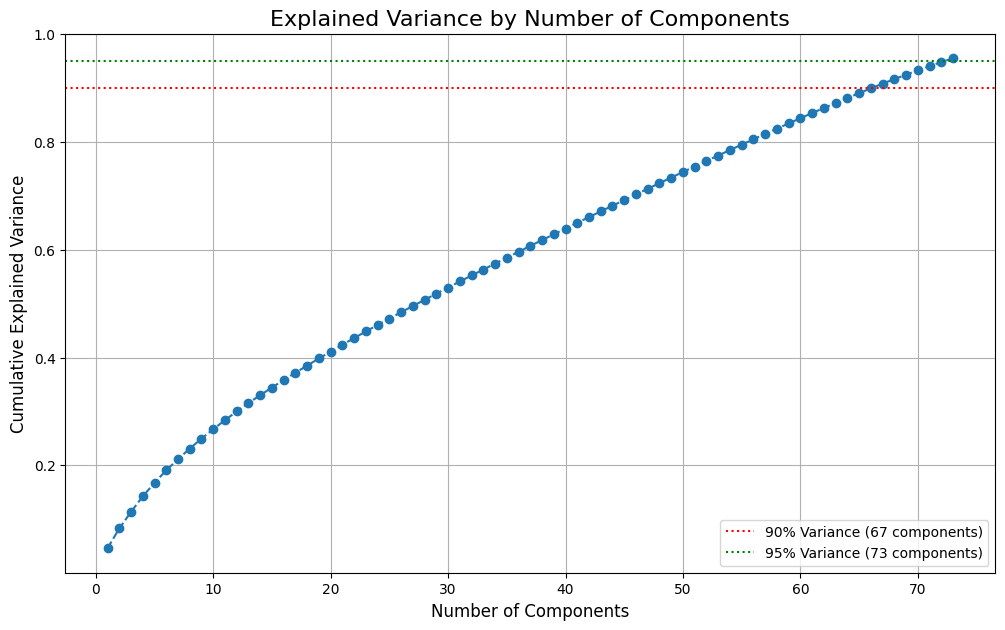

To capture 90% of variance, you need 67 components.
To capture 95% of variance, you need 73 components.


In [25]:
# 2. Calculate the cumulative explained variance
# This shows how much "information" is captured by 1, 2, 3... components
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# 3. Plot the cumulative variance
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

# --- Add helpful lines and labels ---
# Find the point where 90% variance is explained
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
plt.axhline(y=0.90, color='r', linestyle=':', label=f'90% Variance ({n_components_90} components)')

# Find the point where 95% variance is explained
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
plt.axhline(y=0.95, color='g', linestyle=':', label=f'95% Variance ({n_components_95} components)')

plt.title('Explained Variance by Number of Components', fontsize=16)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()
print(f"To capture 90% of variance, you need {n_components_90} components.")
print(f"To capture 95% of variance, you need {n_components_95} components.")

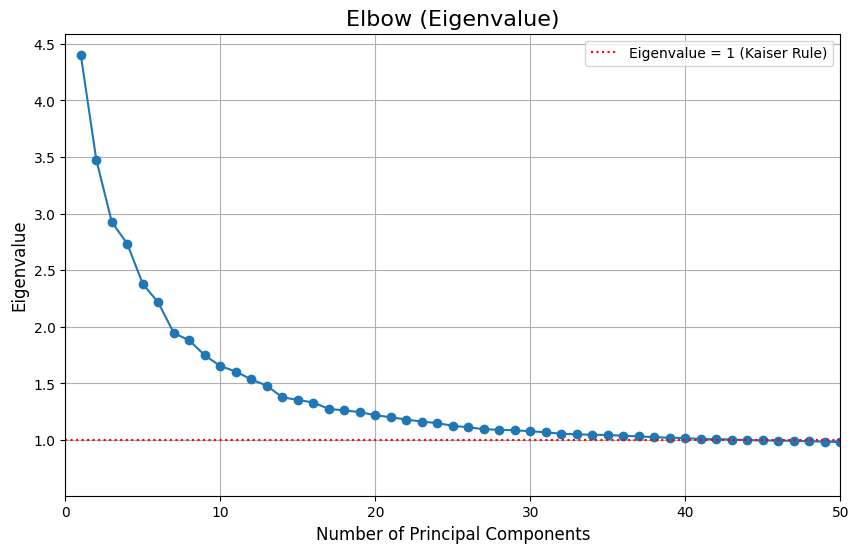

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-')

plt.axhline(y=1, color='r', linestyle=':', label='Eigenvalue = 1 (Kaiser Rule)')

plt.title('Elbow (Eigenvalue)', fontsize=16)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Eigenvalue', fontsize=12)
plt.legend()
plt.grid(True)

# Limit x-axis to the first 50 components
plt.xlim(0, 50)
plt.show()

In [ ]:
n_components_analysis = 67

pca_analysis = PCA(n_components=n_components_analysis)
df_pca_analysis = pca_analysis.fit_transform(df_scaled)


Running linkage on sample of 45385 rows...
Plotting dendrogram...


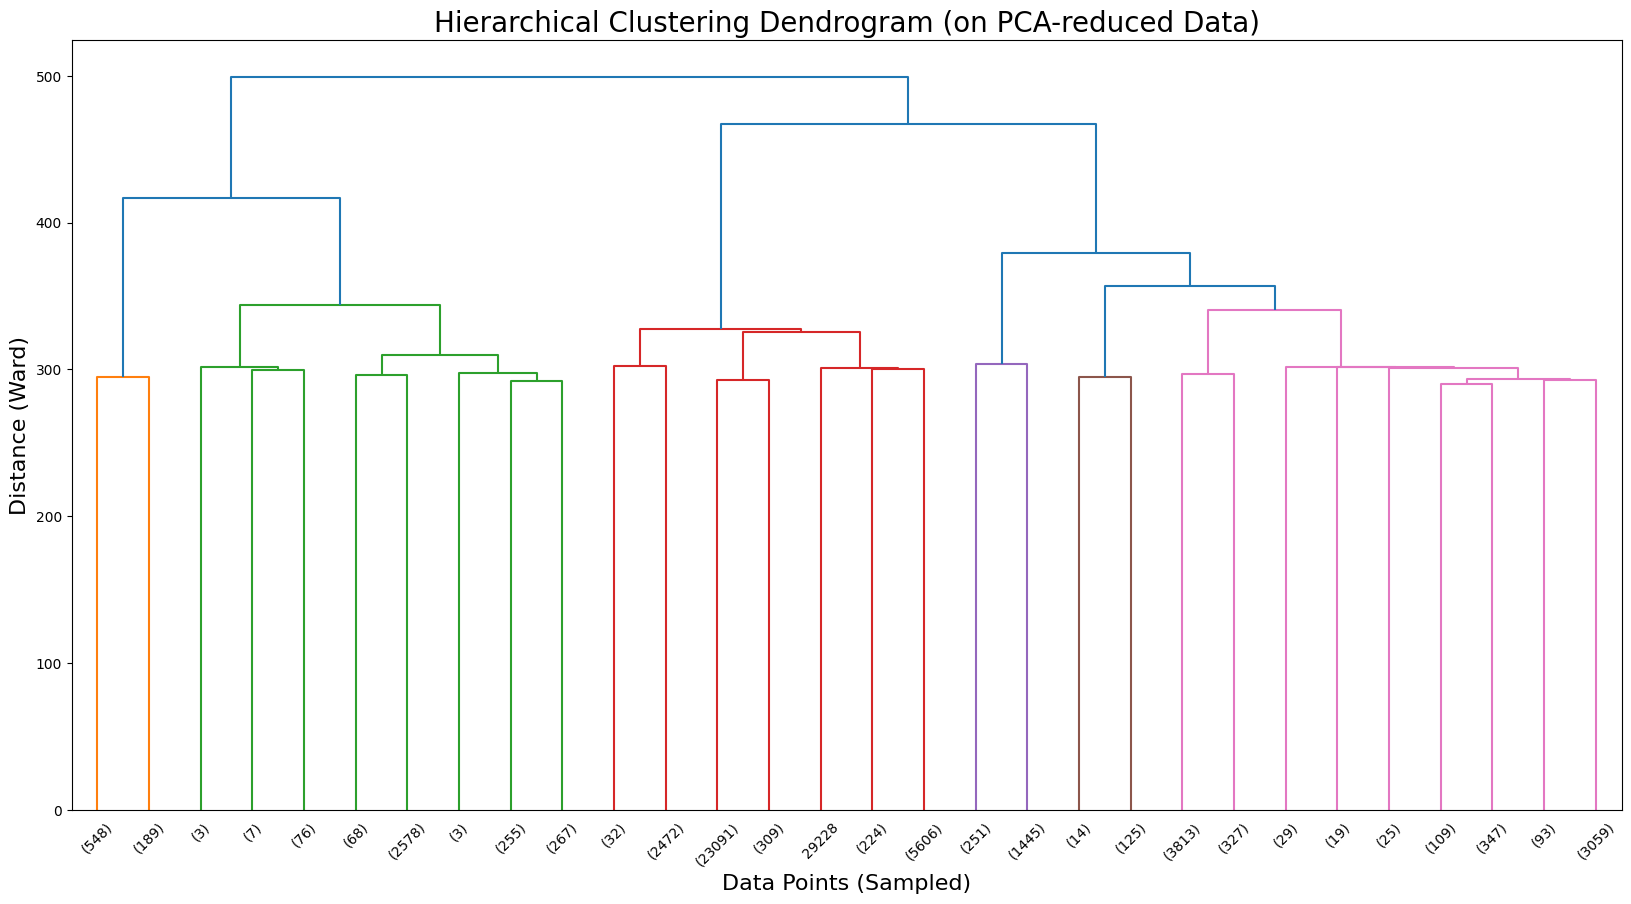

In [89]:
pca_visual = PCA(n_components=2)
df_pca_visual = pca_visual.fit_transform(df_scaled)
df_pca_visual = pd.DataFrame(df_pca_visual, columns=['PCA1', 'PCA2'])

n_sample = 45385
sample_indices = np.random.choice(df_pca_analysis.shape[0], n_sample, replace=False)
df_pca_sample = df_pca_analysis[sample_indices]

print(f"Running linkage on sample of {n_sample} rows...")
Z = linkage(df_pca_sample, method='ward')

print("Plotting dendrogram...")
plt.figure(figsize=(20, 10))
plt.title('Hierarchical Clustering Dendrogram (on PCA-reduced Data)', fontsize=20)
plt.xlabel('Data Points (Sampled)', fontsize=16)
plt.ylabel('Distance (Ward)', fontsize=16)
dendrogram(Z, truncate_mode='lastp', p=30)
plt.show()

In [58]:
min_samples = 20

In [61]:
from kneed import KneeLocator

# X_pca from earlier step
def get_eps_optimal(k):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X_pca)
    distances, indices = neighbors_fit.kneighbors(X_pca)

    # Take the distance to the k-th nearest neighbor
    k_distances = np.sort(distances[:, k-1])
    kneedle = KneeLocator(range(len(k_distances)), k_distances, curve='convex', direction='increasing')
    eps_optimal = k_distances[kneedle.knee]
    print("Optimal eps:", eps_optimal)
    return eps_optimal

In [77]:
params = [(38,10), (38,25), (42,20), (42,30), (46,25), (50,30)]

for eps, ms in params:
    db = DBSCAN(eps=eps, min_samples=ms).fit(X_pca)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = list(labels).count(-1)/len(labels)
    if n_clusters > 1:
        score = silhouette_score(X_pca, labels)
        print(f"eps={eps:.1f}, min_samples={ms}, clusters={n_clusters}, noise={noise_ratio:.2f}, silhouette={score:.3f}")
    else:
        print(f"eps={eps:.1f}, min_samples={ms}, clusters=1, noise={noise_ratio:.2f}")

eps=38.0, min_samples=10, clusters=7, noise=0.00, silhouette=0.739
eps=38.0, min_samples=25, clusters=4, noise=0.00, silhouette=0.738
eps=42.0, min_samples=20, clusters=2, noise=0.00, silhouette=0.741
eps=42.0, min_samples=30, clusters=1, noise=0.00
eps=46.0, min_samples=25, clusters=1, noise=0.00
eps=50.0, min_samples=30, clusters=1, noise=0.00


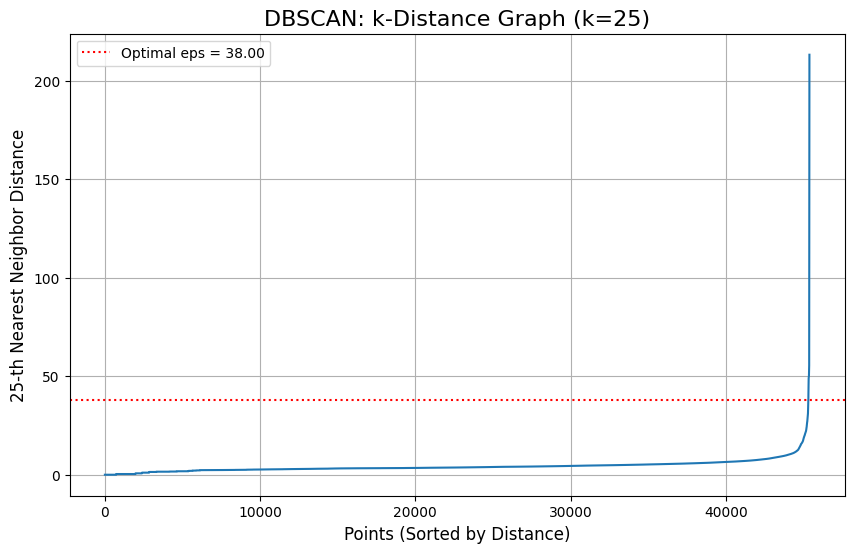

In [82]:
min_samples = 25
k = min_samples
eps_optimal = 38
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Take the distance to the k-th nearest neighbor
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.axhline(y=eps_optimal, color='r', linestyle=':', label=f'Optimal eps = {eps_optimal:.2f}')
plt.title(f'DBSCAN: k-Distance Graph (k={min_samples})', fontsize=16)
plt.xlabel('Points (Sorted by Distance)', fontsize=12)
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [83]:
print(f"Running DBSCAN with eps={eps_optimal} and min_samples={min_samples}...")
dbscan = DBSCAN(eps=eps_optimal, min_samples=min_samples, n_jobs=-1)
db_labels = dbscan.fit_predict(df_pca_analysis)

Running DBSCAN with eps=38 and min_samples=25...



DBSCAN found 3 clusters.
Found 63 noise points (cluster -1).
Plotting DBSCAN cluster results...


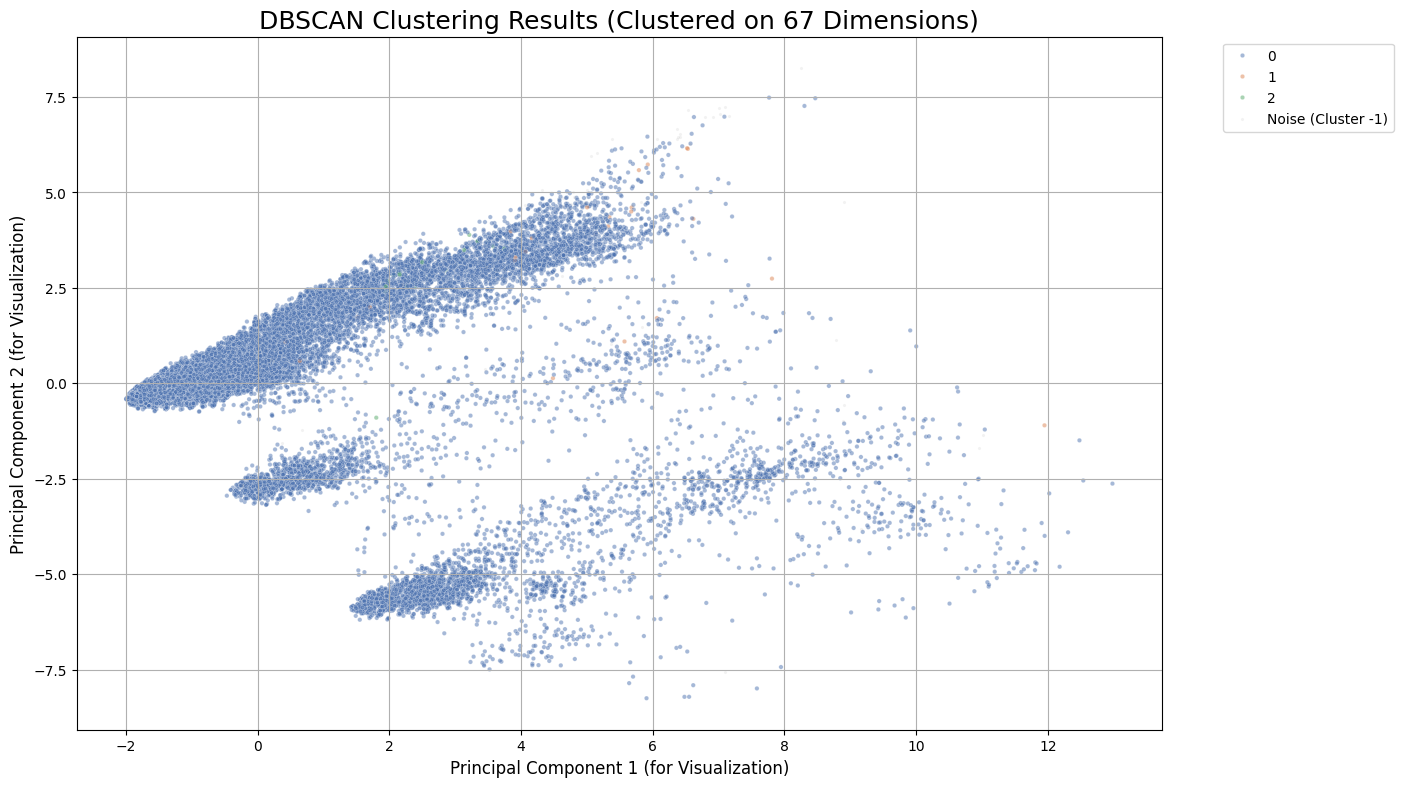

In [84]:
df_pca_visual['db_cluster'] = db_labels
n_clusters_ = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_ = list(db_labels).count(-1)

print(f"\nDBSCAN found {n_clusters_} clusters.")
print(f"Found {n_noise_} noise points (cluster -1).")

print("Plotting DBSCAN cluster results...")
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_pca_visual[df_pca_visual['db_cluster'] != -1], 
    x='PCA1', y='PCA2', hue='db_cluster', 
    palette='deep', s=10, alpha=0.5
)
sns.scatterplot(
    data=df_pca_visual[df_pca_visual['db_cluster'] == -1], 
    x='PCA1', y='PCA2', color='gray', 
    label='Noise (Cluster -1)', s=5, alpha=0.1
)
plt.title(f'DBSCAN Clustering Results (Clustered on {n_components_analysis} Dimensions)', fontsize=18)
plt.xlabel('Principal Component 1 (for Visualization)', fontsize=12)
plt.ylabel('Principal Component 2 (for Visualization)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [85]:

# Add the cluster labels as a new column
df_cluster['db_cluster'] = db_labels
# Get a high-level summary of cluster sizes
print("Cluster sizes:")
print(df_cluster['db_cluster'].value_counts())

Cluster sizes:
db_cluster
 0    45268
-1       63
 1       29
 2       25
Name: count, dtype: int64


In [86]:
# We loop through each cluster number (0, 1, 2, etc.)
# We ignore -1 (noise) for now.
cluster_ids = sorted([c for c in df_cluster['db_cluster'].unique() if c != -1])

for cluster_id in cluster_ids:
    print("\n" + "="*50)
    print(f"--- PROFILING CLUSTER {cluster_id} ---")
    
    # Create a small DataFrame just for this cluster's data
    cluster_df = df_cluster[df_cluster['db_cluster'] == cluster_id]
    
    print(f"Total points in cluster: {len(cluster_df)}")
    
    # --- Check the most common values for key features ---
    # You can add/remove any column you want to check
    
    if 'primary_factor' in cluster_df.columns:
        print("\nPrimary Factor:")
        print(cluster_df['primary_factor'].value_counts(normalize=True).head(3))
        
    if 'manner_of_collision' in cluster_df.columns:
        print("\nManner of Collision:")
        print(cluster_df['manner_of_collision'].value_counts(normalize=True).head(3))

    if 'light_group' in cluster_df.columns:
        print("\nLighting Condition:")
        print(cluster_df['light_group'].value_counts(normalize=True).head(3))

    if 'weather_group' in cluster_df.columns:
        print("\nWeather Condition:")
        print(cluster_df['weather_group'].value_counts(normalize=True).head(3))

    if 'is_weekend' in cluster_df.columns:
        print("\nWeekend vs. Weekday:")
        print(cluster_df['is_weekend'].value_counts(normalize=True).head(3))

print("\n" + "="*50)
print("Analysis complete. Compare these profiles to understand your clusters.")


--- PROFILING CLUSTER 0 ---
Total points in cluster: 45268

Primary Factor:
primary_factor
violations                 0.760184
movement prior to crash    0.201268
driver condition           0.018821
Name: proportion, dtype: float64

Manner of Collision:
manner_of_collision
Rear-End     0.334121
Angle        0.252187
Sideswipe    0.195966
Name: proportion, dtype: float64

Lighting Condition:
light_group
Daylight    0.734492
Dark        0.225192
Twilight    0.023328
Name: proportion, dtype: float64

Weather Condition:
weather_group
Clear/Cloudy     0.919921
Rain             0.062494
Other/Unknown    0.015397
Name: proportion, dtype: float64

Weekend vs. Weekday:
is_weekend
0    0.776663
1    0.223337
Name: proportion, dtype: float64

--- PROFILING CLUSTER 1 ---
Total points in cluster: 29

Primary Factor:
primary_factor
violations                 0.379310
movement prior to crash    0.310345
non-motorist action        0.137931
Name: proportion, dtype: float64

Manner of Collision:
manner


--- 3. K-Means Clustering ---
Calculating K-Means elbow plot...
Optimal K found at k = 4


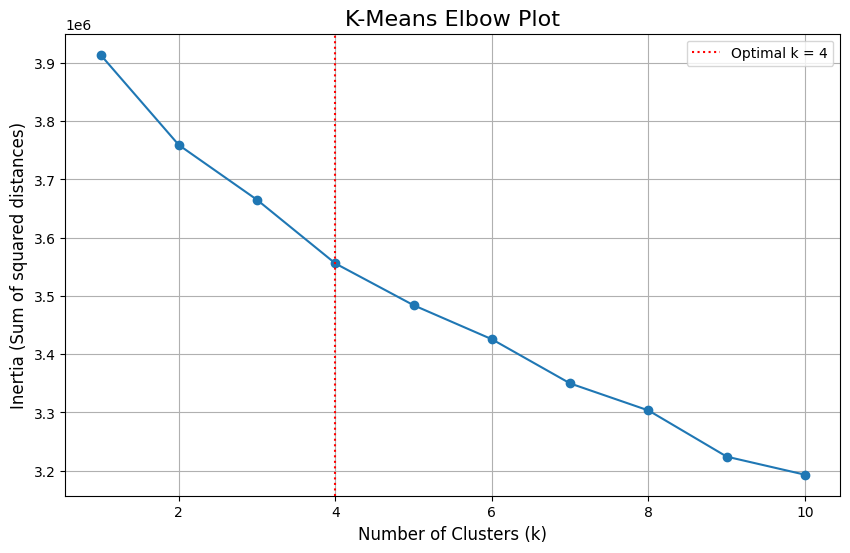

In [87]:
print("\n--- 3. K-Means Clustering ---")

print("Calculating K-Means elbow plot...")
inertia = []
k_range = range(1, 11) 
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(df_pca_analysis)
    inertia.append(kmeans.inertia_)

# Find the elbow with KneeLocator
kneedle_kmeans = KneeLocator(k_range, inertia, curve='convex', direction='decreasing')
k_optimal = kneedle_kmeans.knee

print(f"Optimal K found at k = {k_optimal}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.axvline(x=k_optimal, color='r', linestyle=':', label=f'Optimal k = {k_optimal}')
plt.title('K-Means Elbow Plot', fontsize=16)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Sum of squared distances)', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()


Running K-Means with k=4...
Plotting K-Means cluster results...


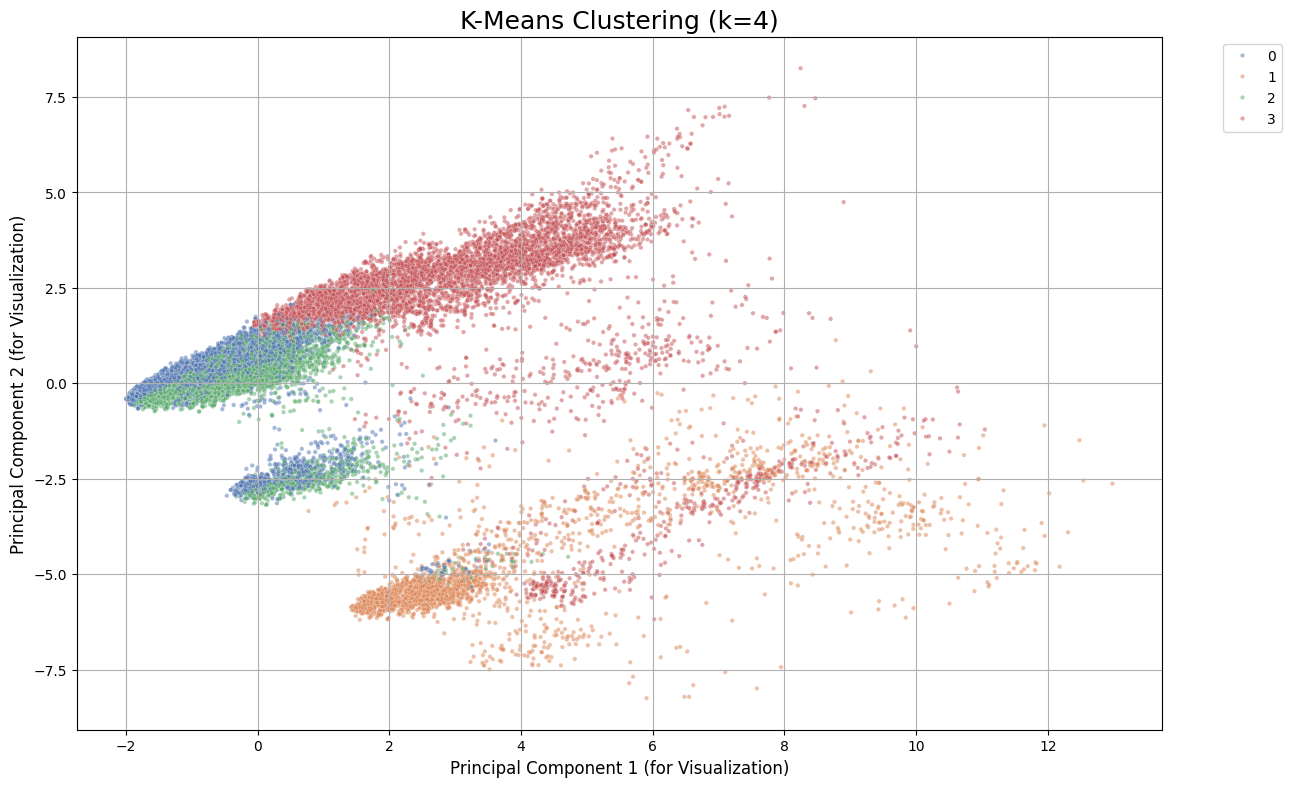

In [88]:
print(f"Running K-Means with k={k_optimal}...")
kmeans = KMeans(n_clusters=k_optimal, n_init=10, random_state=42)
km_labels = kmeans.fit_predict(df_pca_analysis)

df_pca_visual['km_cluster'] = km_labels
print("Plotting K-Means cluster results...")
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_pca_visual, 
    x='PCA1', y='PCA2', hue='km_cluster', 
    palette='deep', s=10, alpha=0.5
)
plt.title(f'K-Means Clustering (k={k_optimal})', fontsize=18)
plt.xlabel('Principal Component 1 (for Visualization)', fontsize=12)
plt.ylabel('Principal Component 2 (for Visualization)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45385 entries, 0 to 45384
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   district             45385 non-null  int64   
 1   crash_occurred_on    45385 non-null  object  
 2   type_of_roadway      45385 non-null  object  
 3   road_surface         45385 non-null  object  
 4   weather_condition    45385 non-null  object  
 5   lighting_condition   45385 non-null  object  
 6   injury               45385 non-null  int64   
 7   fatality             45385 non-null  int64   
 8   hit_and_run          45385 non-null  int64   
 9   pedestrian_involved  45385 non-null  int64   
 10  train_involved       45385 non-null  int64   
 11  intersection         45385 non-null  bool    
 12  vehicle_alignment    45385 non-null  object  
 13  relation_to_roadway  45385 non-null  object  
 14  manner_of_collision  45385 non-null  object  
 15  primary_factor     

In [92]:
# Select only categorical/object columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Iterate over selected columns and print value counts
for col in categorical_cols:
    print(f"--- Value counts for column: {col} ---")
    print(df[col].value_counts())
    print("\n")


--- Value counts for column: crash_occurred_on ---
crash_occurred_on
city street                  22343
interstate                    8782
us highway                    5767
state highway                 5666
off road/private property     2599
parish road                    228
Name: count, dtype: int64


--- Value counts for column: type_of_roadway ---
type_of_roadway
two-way road with no physical separation    20902
one-way road                                12608
two-way road with a physical barrier         6867
two-way road with physical separation        4811
other                                         197
Name: count, dtype: int64


--- Value counts for column: road_surface ---
road_surface
dry                         40213
wet                          4255
unknown                       666
water (standing, moving)      102
ice/frost                      72
other                          35
mud, dirt, gravel              28
snow                            7
slush              